# 📘 Módulo 4 — Introdução às Distribuições de Probabilidade
## Livro Didático Aplicado (Híbrido)

- 🔵 **Conteúdo oficial do módulo 4 (IBM)**
- 🟣 **Conteúdo expandido (Livro Didático)**
- 🟠 **Conteúdo avançado (Opcional, matemático)**

Este notebook segue o mesmo padrão dos módulos anteriores:

- clareza didática,
- profundidade conceitual,
- rigor matemático,
- explicações intuitivas,
- aplicações práticas,
- demonstrações opcionais em `<details>`.

Você pode:
- seguir só o que é 🔵 (curso),
- explorar o 🟣 (livro didático),
- abrir o 🟠 (avançado) quando quiser ir mais fundo.

<a id="indice"></a>
# 📚 Índice

0. [Setup — bibliotecas e dados](#setup)
1. [Números aleatórios e distribuições de probabilidade](#random)
2. [Variáveis aleatórias: discretas e contínuas](#variaveis)
3. [Funções PMF, PDF e CDF](#funcoes)
4. [Distribuição Normal](#normal)
5. [Distribuição t de Student](#tstudent)
6. [Declarando hipóteses (IBM)](#hipotese)
7. [Alfa (α) e valor-p (IBM)](#alpha)
8. [Normal 2](#normal2)
9. [t student 2](#tstudent2)
10. [Aplicações com teaching ratings](#teaching)
11. [Tabela Z — Normal Padrão](#tabelaz)
12. [Exercícios guiados](#exercicios)
13. [Apêndice matemático avançado](#apendice)

<a id="setup"></a>
# 0. Setup — bibliotecas e dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t

plt.style.use("seaborn-v0_8-whitegrid")

🔵 **Dataset teaching ratings (IBM)**

O módulo 4 utiliza o mesmo dataset dos módulos anteriores.
Ele contém:
- avaliações de ensino (`eval`),
- características dos instrutores,
- número de alunos,
- variáveis categóricas e numéricas.

Este dataset será usado para:
- calcular probabilidades,
- padronizar valores (z-score),
- visualizar distribuições,
- aplicar conceitos de normal e t-distribution.

In [ ]:
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv"
ratings_df = pd.read_csv(ratings_url)
ratings_df.to_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv", index=False)
ratings_df.head()

In [2]:
# Carregamento local
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")
ratings_df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


<br>

## 🔵 Conexão com o curso IBM

O módulo 4 apresenta:

1. **Números aleatórios e distribuições de probabilidade**  
   > “Probabilidade é uma medida entre zero e um para a probabilidade de que algo ou algum evento possa ocorrer.”  
   *(conteúdo IBM)*

2. **Variáveis aleatórias e distribuições**  
   > “A distribuição de probabilidade é um modelo teórico que descreve os valores possíveis que qualquer variável aleatória pode assumir junto com a probabilidade de sua ocorrência.”  
   *(conteúdo IBM)*

3. **Distribuição Normal**

4. **Distribuição t de Student**

5. **Declarar hipóteses (Jordan vs Chamberlain)**

6. **Alfa (α) e valor-p**

7. **Probabilidades com teaching ratings**

8. **Tabela Normal Padrão (Z-table)**

Este notebook segue exatamente essa ordem — com explicações ampliadas, rigor matemático e visualizações adicionais.

<br>

## 🟣 Antes de avançar

A partir daqui, entraremos no conteúdo matemático:

- espaço amostral,  
- eventos,  
- variáveis aleatórias,  
- distribuições discretas e contínuas,  
- PMF, PDF, CDF,  
- normal e t-distribution.

Cada seção terá:

- definição clara,  
- explicação intuitiva,  
- interpretação geométrica,  
- exemplos numéricos,  
- gráficos,  
- e aprofundamentos opcionais em `<details>`.

Vamos começar pela base: **probabilidade e números aleatórios**.

<br>

---

<a id="random"></a>
[↑ Índice](#indice)
# 1. Números aleatórios e distribuições de probabilidade

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso introduz probabilidade com a seguinte ideia:

> “Probabilidade é uma medida entre zero e um $ (0 ↔ 1) $ para a probabilidade de que algo ou algum evento possa ocorrer.”  
> *(conteúdo IBM)*

E complementa:

> “A distribuição de probabilidade é um modelo teórico que descreve os valores possíveis <br> que qualquer variável aleatória pode assumir junto com a probabilidade de sua ocorrência.”  
> *(conteúdo IBM)*

Vamos construir isso passo a passo.

## 1.1 Espaço amostral e eventos

| 🟣 Definições | Fundamentos |
|-|-|
| **Espaço amostral** <br> conjunto de todos os resultados possíveis. | $ → \qquad S = \{ \text{todos os resultados possíveis} \} $ |
| **Evento**: <br> subconjunto do espaço amostral. | $ → \qquad A \subseteq S $ |
| **Probabilidade clássica**: <br><br> | $ → \qquad P(A) = \frac{\text{número de resultados favoráveis}}{\text{número de resultados possíveis}} $ |


## 1.2 Exemplo clássico — soma de dois dados

🔵 **Conexão com o curso IBM**

O vídeo do módulo 4 usa exatamente este exemplo para introduzir distribuições discretas.

Vamos reproduzir em Python.

In [4]:
# todos os pares possíveis (dado1, dado2)
valores = [(i, j) for i in range(1, 7) for j in range(1, 7)]
somas = [i + j for i, j in valores]

valores_unicos, contagens = np.unique(somas, return_counts=True)
probs = contagens / contagens.sum()

df_dados = pd.DataFrame({
    "Soma": valores_unicos,
    "Contagem": contagens,
    "Probabilidade": probs
})
df_dados

,Soma,Contagem,Probabilidade
0,2,1,0.027778
1,3,2,0.055556
2,4,3,0.083333
3,5,4,0.111111
4,6,5,0.138889
5,7,6,0.166667
6,8,5,0.138889
7,9,4,0.111111
8,10,3,0.083333
9,11,2,0.055556


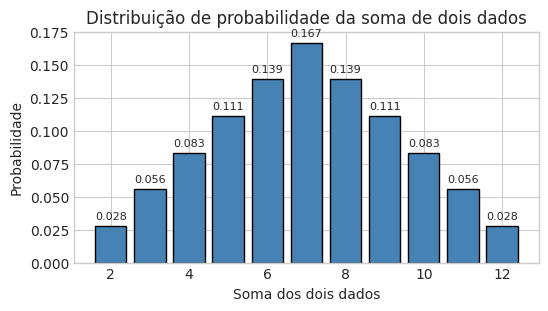

In [5]:
plt.figure(figsize=(6, 3))
plt.bar(valores_unicos, probs, color="steelblue", edgecolor="black")
for x, p in zip(valores_unicos, probs):
    plt.text(x, p + 0.005, f"{p:.3f}", ha="center", fontsize=8)
plt.xlabel("Soma dos dois dados")
plt.ylabel("Probabilidade")
plt.title("Distribuição de probabilidade da soma de dois dados")
plt.show()

🟣 **Interpretação**

- A soma varia de **2** a **12**.
- Nem todas as somas são igualmente prováveis.
- **7** é a soma mais provável.
- **2** e **12** são as menos prováveis.

| A soma das probabilidades é: | $$ → \qquad \sum_{k=2}^{12} P(X = k) = 1 $$ |
|-|-|

<br>

---

<a id="variaveis"></a>
[↑ Índice](#indice)
# 2. Variáveis aleatórias: discretas e contínuas

🟣 **Definição**

Uma **variável aleatória** é uma função que associa números reais a resultados de um experimento aleatório:  
- $ X : \Omega \to \mathbb{R} $

Existem dois tipos principais:

- **Discretas** → valores isolados (contagens).  
- **Contínuas** → valores em intervalos (medidas).

| 2.1 Variáveis discretas | 2.2 Variáveis contínuas |
|-|-|
| <br> **Exemplos:** <br> - número de alunos, <br> - número de chamadas, <br> - soma de dois dados.  <br><br><br> A probabilidade é dada por uma **PMF (Probability Mass Function)** | <br> **Exemplos:** <br> - altura, <br> - idade, <br> - tempo, <br> - notas em escala contínua. <br><br> A probabilidade é dada por uma **PDF (Probability Density Function)** <br> |

<br>

---

<a id="funcoes"></a>
[↑ Índice](#indice)
# 3. PMF, PDF e CDF

Agora que entendemos variáveis aleatórias discretas e contínuas, vamos formalizar
as três funções fundamentais que descrevem distribuições de probabilidade:

- **PMF** → Probability Mass Function (função de massa de probabilidade)  
- **PDF** → Probability Density Function (função densidade de probabilidade)  
- **CDF** → Cumulative Distribution Function (função de distribuição acumulada)  

Cada uma delas descreve um aspecto diferente da distribuição.

## 3.1 PMF — Probability Mass Function (variáveis discretas)

A PMF **atribui uma probabilidade exata a cada valor possível**:
- $ P(X = x_k) $

- Exemplos típicos:
    - número de chamadas,
    - número de alunos,
    - **soma de dois dados**.

<br>

#### 🔗 **Conexão com o gráfico 1.2**

O gráfico da *soma de dois dados* mostrado no item **1.2** é **exatamente uma PMF**:

- valores possíveis: 2 a 12  
- cada valor tem uma probabilidade específica  
- a soma das probabilidades é 1  

Ou seja, o gráfico 1.2 é a **visualização da PMF** da variável aleatória:

- $ X = \text{soma de dois dados} $



## 3.2 PDF — Probability Density Function (variáveis contínuas)

Para variáveis contínuas, a probabilidade não é atribuída a pontos individuais.
- $  P(X = x) $
- porque a probabilidade em um ponto é **zero**.

Em vez disso, usamos uma **função densidade de probabilidade**, ou PDF em $ f(x) $

| A PDF descreve como a probabilidade está distribuída ao longo dos valores possíveis. <br> A probabilidade de $ X $ cair em um intervalo é dada pela área sob a curva: | $$ → \qquad P(a < X < b) = \int_a^b f(x)\,dx $$ |
|-|-|

- **Isso é o ponto central das distribuições contínuas:**
    - a curva mostra **densidade**, não probabilidade,
    - probabilidades são sempre **áreas**,
    - a área total sob a curva é igual a **1**.

- **Exemplos:**
    - altura,
    - tempo,
    - notas contínuas,
    - distribuição normal.

Para ilustrar, vamos usar uma PDF contínua comum (a Normal Padrão),  
mas o estudo completo da Normal será feito no item 4.

<br>

### Visualização da curva PDF

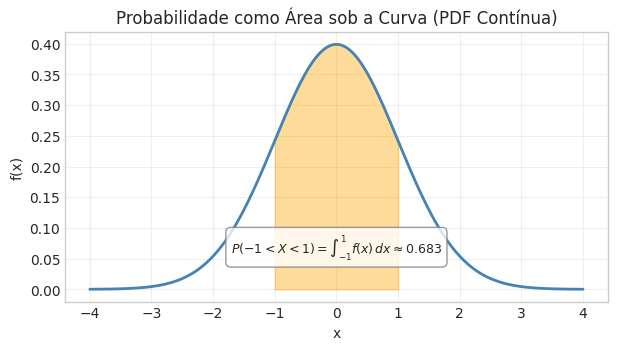

In [43]:
# eixo x e PDF da normal padrão
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)

# intervalo [a, b] para destacar a área
a, b = -1, 1
x_fill = np.linspace(a, b, 200)
y_fill = norm.pdf(x_fill, 0, 1)

# probabilidade P(a < X < b)
prob = norm.cdf(b) - norm.cdf(a)

plt.figure(figsize=(7, 3.5))
plt.plot(x, y, color="steelblue", linewidth=2)
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.4)
plt.title("Probabilidade como Área sob a Curva (PDF Contínua)"); plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(alpha=0.3)

# anotação da probabilidade no gráfico
plt.text(0, max(y)*0.15,
    fr"$P({a} < X < {b}) = \int_{{{a}}}^{{{b}}} f(x)\,dx \approx {prob:.3f}$",
    ha="center", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
)

plt.show()


## 3.3 CDF — Cumulative Distribution Function

| Definição | Demonstração |
|-|-|
| <br> A CDF **acumula probabilidade da esquerda para a direita**: <br><br> | $ → \qquad  F(x) = P(X \le x) $ |
| Para variáveis contínuas: | $$ → \qquad F(x) = \int_{-\infty}^{x} f(t)\,dt $$ |


## 3.4 Visualização da CDF discreta → Soma de dois dados

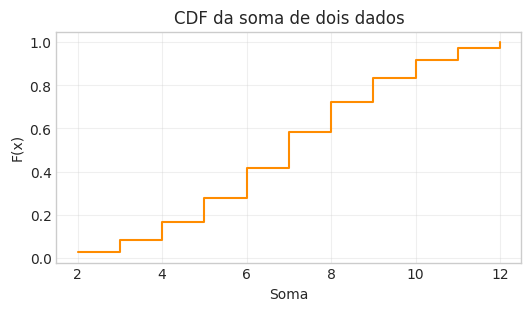

In [44]:
cdf_vals = np.cumsum(probs)

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(6, 3))
plt.step(valores_unicos, cdf_vals, where="post", color="darkorange")
plt.xlabel("Soma"); plt.ylabel("F(x)"); plt.title("CDF da soma de dois dados"); plt.grid(alpha=0.3)
plt.show()




🟣 **Interpretação**

- A CDF é **crescente**.
- Começa em **0** e termina em **1**.
- Em distribuições discretas, aparece como **degraus**.

- Exemplo:

    - $ F(6) = P(X \le 6) $  
    - $ P(X > 6) = 1 - F(6) $

### 🟠 Explicação avançada — Convolução e soma de distribuições

A soma de dois dados é a **convolução** de duas distribuições uniformes discretas.  
(vide item **1.2**)

| Se $X$ e $Y$ são independentes: | $$ → \qquad P(X+Y = k) = \sum_{i} P(X=i)\,P(Y=k-i) $$ |
|-|-|

- Para dados:
    - cada valor tem probabilidade $1/6$,
    - a soma resulta em uma distribuição triangular.

💡 A simulação Monte Carlo confirma essa estrutura.

<br>

---

<a id="normal"></a>
[↑ Índice](#indice)
# 4. Distribuição Normal

A distribuição Normal é a distribuição contínua mais importante da estatística.  
Ela aparece no módulo 4 do curso IBM como:  

🔵 **“uma das distribuições mais usadas na análise estatística e até mesmo nas conversas diárias.”**

## 4.1 O que é a distribuição Normal?

🔵 **Conexão com o curso IBM**


A Normal é uma distribuição **contínua**, **simétrica**, em forma de sino.

- Ela é definida por dois parâmetros:
    - média: $\mu$
    - desvio padrão: $\sigma$

- Interpretação:
    - $\mu$ → centro da curva  
    - $\sigma$ → espalhamento  

| A área total sob a curva é **1**: | $$ → \qquad \int_{-\infty}^{+\infty} f(x)\,dx = 1 $$ |
|-|-|

## 4.2 Visualização da Normal Padrão $N(0,1)$

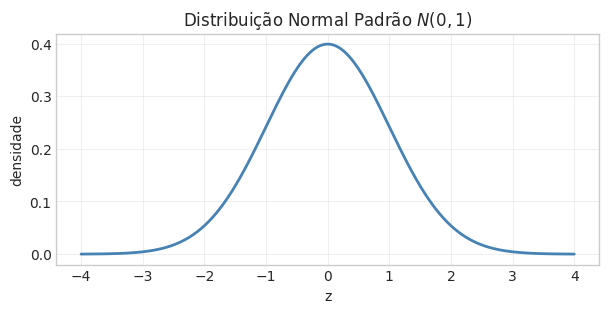

In [65]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue", linewidth=2)
plt.title("Distribuição Normal Padrão $N(0,1)$"); plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

**Interpretação**

- A curva é simétrica em torno de 0.  
- A maior parte da densidade está entre -3 e +3.  
- A altura da curva representa **densidade**, não probabilidade.  
- Probabilidades são **áreas** sob a curva.

## 4.3 A fórmula da PDF Normal (conteúdo IBM)

| O curso apresenta a fórmula: | $$ → \qquad f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) $$ |
|-|-|

- onde: $e^{u} \ \equiv \ exp(u)$
- Essa é a função densidade da Normal.

## 4.4 Probabilidade como área sob a curva

| Para variáveis contínuas: | $$ → \qquad P(a < X < b) = \int_a^b f(x)\,dx $$ |
|-|-|

- Vamos visualizar a área entre -1 e 1.

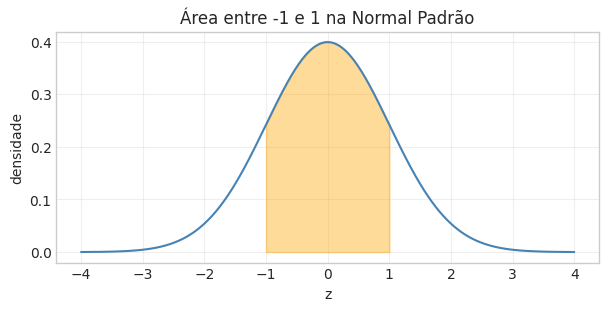

In [66]:
x_fill = np.linspace(-1, 1, 200)
y_fill = norm.pdf(x_fill, 0, 1)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.4)
plt.title("Área entre -1 e 1 na Normal Padrão")
plt.xlabel("z")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

| **Interpretação** |  $$ → \qquad P(-1 < Z < 1) \approx 0.68 $$ |
|-|-|

- Este é o **empirical rule**:
    - 68% dos valores estão em $\mu \pm 1\sigma$  
    - 95% em $\mu \pm 2\sigma$  
    - 99.7% em $\mu \pm 3\sigma$

## 4.5 Padronização (z-score)

| O curso IBM usa a padronização para calcular probabilidades: | $$ → \qquad Z = \frac{X - \mu}{\sigma} $$ |
|-|-|

- Isso transforma qualquer Normal em $N(0,1)$.

## 4.6 CDF da Normal Padrão

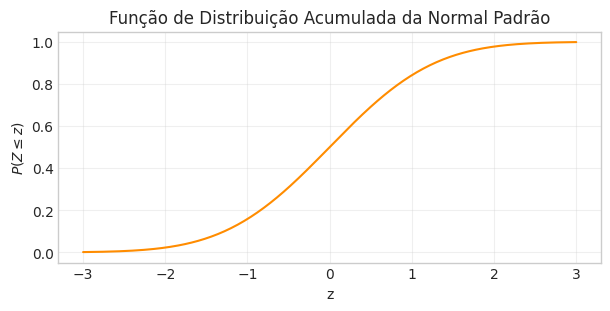

In [76]:
z_vals = np.linspace(-3, 3, 301)
cdf_vals = norm.cdf(z_vals)

plt.figure(figsize=(7, 3))
plt.plot(z_vals, cdf_vals, color="darkorange")
plt.title("Função de Distribuição Acumulada da Normal Padrão")
plt.xlabel("z")
plt.ylabel(r"$P(Z \leq z)$")
plt.grid(alpha=0.3)
plt.show()

**Leitura da CDF**

- $P(Z \le 0) = 0.5$  
- $P(Z \le 1.44) \approx 0.925$  
- $P(Z \le -2) \approx 0.0228$

### 🟠 Explicação avançada — Por que a PDF tem essa forma?

- A forma da PDF normal surge de três requisitos:

    1. **Simetria**  
    2. **Decaimento suave**  
    3. **Área total = 1**

| A constante  | $$ → \qquad \frac{1}{\sigma\sqrt{2\pi}} $$ |
|-|-|
  
- é obtida usando coordenadas polares.

<br>

---

<a id="tstudent"></a>
[↑ Índice](#indice)
# 5. Distribuição t de Student

No módulo 4, o curso IBM apresenta a distribuição t como:

🔵 **“A outra distribuição estatística comumente usada é conhecida como distribuição T de Student.”**

- Ela é usada quando:

    - temos **amostras pequenas**,  
    - não conhecemos o desvio padrão populacional,  
    - precisamos comparar médias.

## 5.1 Motivação (conteúdo IBM)

🔵 **Conexão com o curso IBM**

Quando usamos o desvio padrão amostral $s$ para estimar $\sigma$, introduzimos variabilidade extra.

- Em amostras pequenas:

    - $s$ varia muito,  
    - isso aumenta a incerteza,  
    - a distribuição resultante tem **caudas mais pesadas**.

**A distribuição t modela exatamente essa incerteza.**

## 5.2 Visualização: Normal vs t

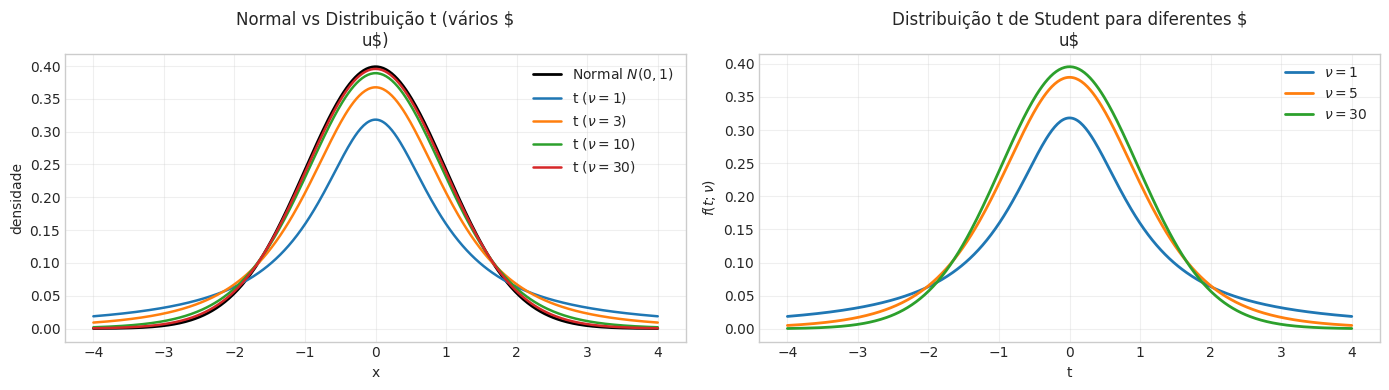

In [ ]:
x = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1 — Normal vs t(df)
axes[0].plot(x, norm.pdf(x), label="Normal $N(0,1)$", color="black", linewidth=2)
for df in [1, 3, 10, 30]:
    axes[0].plot(x, t.pdf(x, df), label=fr"t ($\nu={df}$)", linewidth=1.8)
axes[0].set_title("Normal vs Distribuição t (vários $\nu$)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("densidade"); axes[0].grid(alpha=0.3); axes[0].legend()

# Gráfico 2 — t isolada (ν=1,5,30)
for df in [1, 5, 30]:
    axes[1].plot(x, t.pdf(x, df), label=fr"$\nu={df}$", linewidth=2)
axes[1].set_title("Distribuição t de Student para diferentes $\nu$")
axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$f(t;\nu)$"); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 5.3 Definição formal (conteúdo IBM simplificado)

Depois de observar nos gráficos como as curvas $t$ mudam conforme o valor de $\nu$, podemos agora entender
o que esse parâmetro realmente significa.

A distribuição t depende de um único parâmetro:

- $ \nu = n − 1 $

- onde:
    - $n$ é o tamanho da amostra
    - o $“−1”$ aparece porque estimar a média amostral cria uma restrição e reduz a liberdade dos dados

<br>

✔ **Intuição prática**

| Quando calculamos a média $\bar{x}$, os desvios em relação à média precisam somar zero: | $$ → \qquad \sum_{i=1}^{n} (x_i - \bar{x}) = 0 $$ |
|-|-|

Isso significa que apenas $n−1$ desvios podem variar livremente.  
Por isso dizemos que a distribuição $t$ tem $\nu = n−1$ graus de liberdade.

<br>

### 🔵 Como ν afeta a forma da distribuição t

- Os gráficos mostraram que a t pode ser:
    - muito mais espalhada que a Normal
    - ou quase idêntica a ela

Isso depende exclusivamente de ν:

| $\nu$ | Interpretação | Forma da curva |
| --- | --- | --- |
| 1 | pouquíssima informação sobre a variabilidade | caudas muito pesadas |
| 3 | ainda bastante incerteza | caudas pesadas |
| 10 | variabilidade mais estável | quase Normal |
| 30 | muita informação | praticamente Normal |


- **Quanto maior ν:**

    - mais estável é a estimativa do desvio padrão amostral
    - menor é a incerteza
    - mais a distribuição t se aproxima da Normal

### 🟠 Explicação avançada (definição matemática completa)

A distribuição t surge da combinação entre:
- uma variável Normal padrão
- e uma variável qui-quadrado escalada pelos graus de liberdade

Em notação matemática:

- Se
    - $ Z \sim N(0,1) $
    - $ V \sim \chi^2_{\nu}, $

| então a variável | $$ → \qquad T = \frac{Z}{\sqrt{V/\nu}} $$ |
|-|-|

- segue uma distribuição $t$ de Student com $\nu$ graus de liberdade.

<br>

✔ **Por que isso gera caudas pesadas?**

- O numerador $Z$ representa a variabilidade “normal”.
- O denominador $\sqrt{V/\nu}$ representa a incerteza na estimativa do desvio padrão.
- Quando $\nu$ é pequeno, o termo $V/\nu$ varia muito → denominador instável → caudas pesadas.
- Quando $\nu$ cresce, $V/\nu \to 1$ → denominador estável → a distribuição $t$ converge para a Normal.

<br>

### 🟠 A PDF completa da distribuição $t$

| A função densidade de probabilidade é: | $$ → \qquad f(t;\nu) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)} {\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}} $$ |
|-|-|

- Essa fórmula mostra explicitamente:

    - o papel de $\nu$ no achatamento da curva,
    - o decaimento mais lento das caudas,
    - a transição suave para a Normal quando $\nu \to \infty$.

🎯 *Resumo final*

- $\nu = n - 1$ porque estimar a média consome 1 grau de liberdade.
- $\nu$ controla a incerteza na estimativa do desvio padrão.
- $\nu$ pequeno → $t$ com caudas pesadas (como vimos no gráfico).
- $\nu$ grande → $t \approx Normal$.
- A distribuição $t$ é essencial quando $\sigma$ é desconhecido e substituído por $s$.


## 5.4 Aplicação prática — teaching ratings

O curso IBM pergunta:

🔵 **“A pontuação da avaliação do instrutor difere por sexo?”**

Antes do teste formal (módulo 5), vamos apenas visualizar estatísticas básicas.

In [87]:
ratings_df.groupby("gender")["eval"].agg(["mean", "std", "count"]).reset_index()

,gender,mean,std,count
0,female,3.901026,0.538803,195
1,male,4.069030,0.556652,268


**Interpretação**

- As médias são próximas.  
- As amostras têm tamanhos diferentes.  
- A variabilidade é moderada.  

Isso motiva o uso da **distribuição t** para comparar médias.

## 5.5 Intervalos de confiança com distribuição t

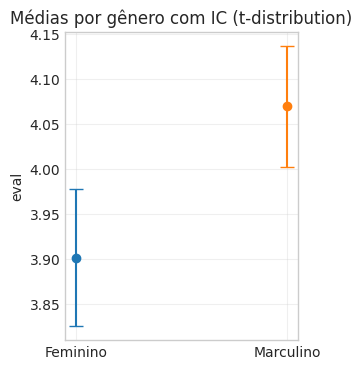

In [123]:
stats = ratings_df.groupby("gender")["eval"].agg(["mean", "std", "count"])

plt.figure(figsize=(3, 4))

for i, gender in enumerate(stats.index):
    mean = stats.loc[gender, "mean"]
    sd = stats.loc[gender, "std"]
    n = stats.loc[gender, "count"]
    se = sd / np.sqrt(n)
    df = n - 1
    t_crit = t.ppf(0.975, df)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se

    plt.errorbar(i, mean, yerr=[[mean-ci_low], [ci_high-mean]],
                 fmt="o", capsize=5, label=gender)

plt.xticks([0, 1],["Feminino", "Marculino"])
plt.ylabel("eval")
plt.title("Médias por gênero com IC (t-distribution)")
plt.grid(alpha=0.3)
plt.show()

**Interpretação**

O gráfico compara as médias de avaliação entre homens e mulheres e mostra seus intervalos de confiança baseados na distribuição $t$.

- As médias são próximas ($\approx 3.9$ para mulheres e $\approx 4.1$ para homens).
- Os intervalos de confiança **se sobrepõem de forma ampla**.
- Isso indica que a diferença observada pode ser explicada pela **variação natural da amostra**, e não necessariamente por uma diferença real entre os grupos.

Em outras palavras:

> **Visualmente, não há evidência forte de que as avaliações diferem por sexo.**

*O teste estatístico formal, que confirmará ou não essa impressão, será feito no módulo 5.*

<br>

---

<a id="hipotese"></a>
[↑ Índice](#indice)
# 6. Declarando hipóteses (IBM)

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta o conceito de hipótese usando o exemplo clássico:

> comparar as médias de pontos por jogo de Michael Jordan e Wilt Chamberlain.

A ideia central é:

- formular uma **hipótese nula** ($H_0$),
- formular uma **hipótese alternativa** ($H_a$),
- definir o tipo de comparação entre médias.

Este é um passo essencial antes de qualquer teste estatístico.

## 6.1 O que é uma hipótese estatística?

Uma **hipótese estatística** é uma afirmação sobre um parâmetro populacional.

Exemplos de parâmetros:

- média populacional: $\mu$
- diferença de médias: $\mu_1 - \mu_2$
- proporção populacional: $p$

No módulo 4, o foco é:

- $ \mu_J \quad \text{vs} \quad \mu_C $

onde:
- $\mu_J$ = média de pontos por jogo de Michael Jordan  
- $\mu_C$ = média de pontos por jogo de Wilt Chamberlain

## 6.2 Exemplo IBM — Jordan vs Chamberlain

O curso apresenta os valores:

- Jordan: média $ \approx 30.12 $ pontos por jogo  
- Chamberlain: média $ \approx 30.06 $ pontos por jogo  

A diferença é pequena, mas queremos saber:

> - **Existe evidência estatística de que as médias são diferentes?**

Para isso, precisamos declarar hipóteses.

## 6.3 Três formas de declarar hipóteses

Existem **três estruturas possíveis**, dependendo da pergunta de interesse.

### 🔹 Caso 1 — Teste bilateral (two-tailed)

- **Pergunta:**

    > As médias são diferentes?

**Hipóteses:**

- $ H_0: \mu_J = \mu_C \ \ \ → \ nula $
- $ H_a: \mu_J \ne \mu_C \ \ \ → \ alternativa $

Interpretação:
- Não assumimos direção.
- Qualquer diferença (para cima ou para baixo) é relevante.

### 🔹 Caso 2 — Teste unilateral à esquerda (left-tailed)

**Pergunta:**

> - Jordan marcou **menos** que Chamberlain?

**Hipóteses:**

- $ H_0: \mu_J \ge \mu_C \ \ \ → \ nula $
- $ H_a: \mu_J < \mu_C \ \ \ → \ alternativa $

### 🔹 Caso 3 — Teste unilateral à direita (right-tailed)

**Pergunta:**

> - Jordan marcou **mais** que Chamberlain?

**Hipóteses:**

- $ H_0: \mu_J \le \mu_C \ \ \ → \ nula $
- $ H_a: \mu_J > \mu_C \ \ \ → \ alternativa $

## 6.4 Interpretação geométrica das hipóteses

Em qualquer teste, a hipótese alternativa define **qual região da distribuição** será usada para avaliar evidência contra $H_0$.

- Teste bilateral → duas caudas  
- Teste unilateral → uma cauda  

Vamos visualizar isso.

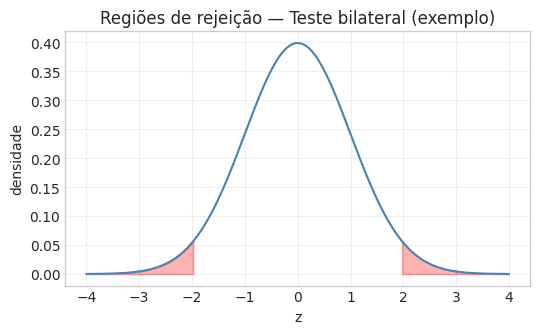

In [11]:
# Visualização das regiões de hipótese (genérica)
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(6, 3.3))
plt.plot(x, y, color="steelblue")

# regiões de rejeição (exemplo com alpha=0.05)
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)

plt.fill_between(x, y, where=(x < -z_crit), color="red", alpha=0.3)
plt.fill_between(x, y, where=(x >  z_crit), color="red", alpha=0.3)
plt.title("Regiões de rejeição — Teste bilateral (exemplo)"); plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas vermelhas representam regiões onde rejeitaríamos $H_0$.
- A área total dessas regiões é igual a $\alpha$.
- A forma da região depende da hipótese alternativa.

### 🟠 Explicação avançada — Hipóteses como conjuntos de parâmetros

**Em termos formais:**

- A hipótese nula $H_0$ é um **conjunto de valores possíveis** para o parâmetro.
- A hipótese alternativa $H_a$ é o **complemento** desse conjunto.

Exemplo bilateral:

- $ H_0 = \{\mu_J - \mu_C = 0\} \ \ \ → \ nula $
- $ H_a = \{\mu_J - \mu_C \ne 0\} \ \ \ → \ alternativa $

Em testes unilaterais:

- $ H_0 = \{\mu_J - \mu_C \ge 0\} \ \ \ → \ nula $
- $ H_a = \{\mu_J - \mu_C < 0\} \ \ \ → \ alternativa $

Essa visão é essencial para entender testes mais avançados no módulo 5.

<br>

---

<a id="alpha"></a>
[↑ Índice](#indice)
# 7. Alfa (α) e valor‑p (IBM)

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta dois conceitos fundamentais para qualquer teste estatístico:

- **α (alfa)** → nível de significância  
- **valor‑p** → medida de evidência contra a hipótese nula  

Esses conceitos aparecem no módulo 4 porque são necessários para interpretar:
- probabilidades na cauda da distribuição normal,
- regiões críticas,
- decisões estatísticas simples.

O teste completo só aparece no módulo 5, mas a base conceitual está aqui.

## 7.1 O que é o nível de significância (α)?

O **nível de significância** é a probabilidade de rejeitar a hipótese nula quando ela é verdadeira.

| <br> Em outras palavras: <br><br> | $ → \qquad \alpha = P(\text{erro tipo I}) $ |
|-|-|

- Valores típicos:
    - 0.10  
    - 0.05  
    - 0.01  

- Interpretação:
    - α define **o tamanho da região de rejeição**.
    - Quanto menor α, mais “conservador” é o teste.

## 7.2 Visualização geométrica de α

Vamos visualizar α = 0.05 em um teste bilateral.

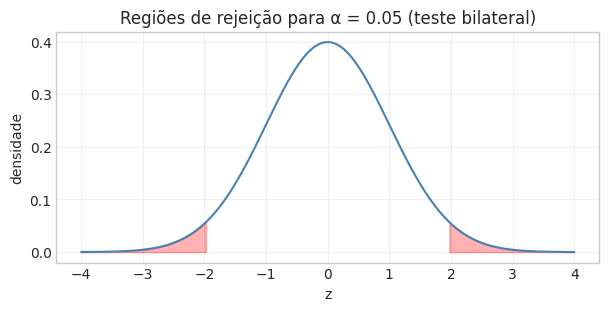

In [20]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")

# regiões de rejeição
plt.fill_between(x, y, where=(x < -z_crit), color="red", alpha=0.3)
plt.fill_between(x, y, where=(x >  z_crit), color="red", alpha=0.3)
plt.title("Regiões de rejeição para α = 0.05 (teste bilateral)"); plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas vermelhas somam **0.05**.
- Cada cauda tem **0.025**.
- Valores extremos (muito distantes da média) caem nessas regiões.

Isso representa a probabilidade de rejeitar $H_0$ **mesmo quando ela é verdadeira**.

## 7.3 O que é o valor‑p?

O **valor‑p** é a probabilidade de obter um resultado tão extremo quanto o observado, **assumindo que $H_0$ é verdadeira**.

| <br> Formalmente: <br><br> | $ → \qquad \text{valor‑p} = P(\text{estatística tão ou mais extrema} \mid H_0) $ |
|-|-|

- Interpretação:

    - valor‑p pequeno → evidência contra $H_0$  
    - valor‑p grande → dados compatíveis com $H_0$

## 7.4 Regra de decisão (módulo 4)

O módulo 4 apresenta a regra básica:

- Se **valor‑p < α** → rejeitamos $H_0$  
- Se **valor‑p ≥ α** → não rejeitamos $H_0$

O teste completo (estatística, distribuição, decisão formal) será tratado no módulo 5.

## 7.5 Visualização geométrica do valor‑p

Vamos ilustrar o valor‑p para um teste bilateral.

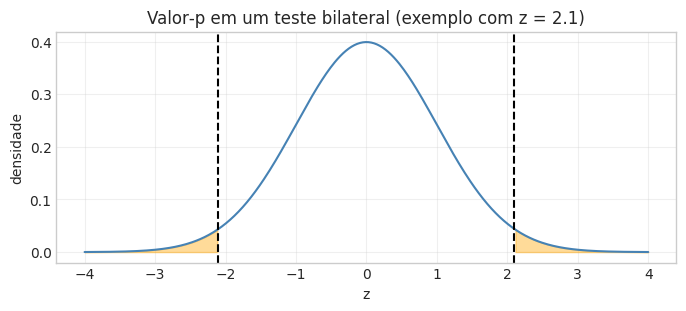

In [25]:
# exemplo: z observado
z_obs = 2.1

plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

# áreas do valor-p
plt.fill_between(x, y, where=(x >  z_obs), color="orange", alpha=0.4)
plt.fill_between(x, y, where=(x < -z_obs), color="orange", alpha=0.4)

plt.axvline(z_obs, color="black", linestyle="--")
plt.axvline(-z_obs, color="black", linestyle="--")

plt.title("Valor‑p em um teste bilateral (exemplo com z = 2.1)")
plt.xlabel("z")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas laranja representam o valor‑p.
- Quanto maior o valor‑p, maior a área.
- Quanto menor o valor‑p, mais “extremo” é o valor observado.

## 7.6 Exemplo numérico simples

Suponha:
- estatística observada: $z = 1.8$
- teste bilateral

O valor‑p é:

- $ \text{valor‑p} = 2 \cdot (1 - F(1.8)) $

In [3]:
z = 1.8
p_value = 2 * (1 - norm.cdf(z))
p_value

np.float64(0.07186063822585154)

🟣 **Interpretação**

- Se α = 0.05 → **não rejeitamos** $H_0$  
- Se α = 0.10 → **rejeitamos** $H_0$  

Isso mostra como α influencia a decisão.

### 🟠 Explicação avançada — valor‑p como integral da cauda

| Descrição | Demonstração |
|-|-|
| Para um teste bilateral: | $ → \qquad \text{valor‑p} = 2 \int_{z_{\text{obs}}}^{\infty} f(z)\,dz $ |
| Para um teste unilateral à direita: | $ → \qquad \text{valor‑p} = \int_{z_{\text{obs}}}^{\infty} f(z)\,dz $ |
| Para um teste unilateral à esquerda: | $ → \qquad \text{valor‑p} = \int_{-\infty}^{z_{\text{obs}}} f(z)\,dz $ |

- Em todos os casos, o valor‑p é uma **área sob a curva**.

<br>

---

<a id="normal2"></a>
[↑ Índice](#indice)
# 8. Distribuição Normal | 2

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta a distribuição normal como:

> - “uma das distribuições mais usadas na análise estatística e até mesmo nas conversas diárias.”

| <br> E mostra sua fórmula: <br><br> | $$ → \qquad f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) $$ |
|-|-|

- onde: $e^{u} \ \equiv \ exp(u)$

Vamos entender essa função com profundidade, intuição e visualização.

## 8.1 O que é a distribuição normal?

A distribuição normal é uma distribuição **contínua**, **simétrica**, em forma de sino.

Ela é definida por dois parâmetros:

- **média**: $\mu$  
- **desvio padrão**: $\sigma$

Interpretação:
- $\mu$ → centro da curva  
- $\sigma$ → espalhamento da curva  

| A área total sob a curva é **1**: | $$ → \qquad \int_{-\infty}^{+\infty} f(x)\,dx = 1 $$ |
|-|-|

## 8.2 Visualização da Normal Padrão $N(0,1)$

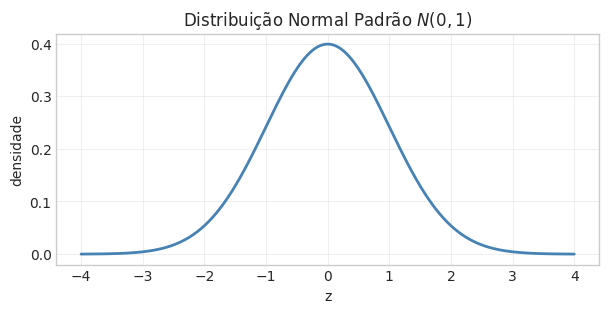

In [4]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue", linewidth=2)
plt.title("Distribuição Normal Padrão $N(0,1)$")
plt.xlabel("z")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- A curva é simétrica em torno de **0**.
- A maior parte da densidade está entre **−3** e **+3**.
- A altura da curva representa **densidade**, não probabilidade.
- Probabilidades são **áreas** sob a curva.

## 8.3 A fórmula da PDF normal

| Descrição | Demonstração |
|-|-|
| A PDF da normal é: | $$ → \qquad f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) $$ |
| Cada parte tem um papel: | $$ → \qquad \frac{1}{\sigma\sqrt{2\pi}} → garante \ que \ a \ área \ total \ seja \ 1 $$ $$ → \qquad  \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) → controla \ o \ formato \ da \ curva $$ |

- onde: $e^{u} \ \equiv \ exp(u)$
- Quanto maior a distância de $x$ até $\mu$, menor a densidade.

### 🟠 Explicação avançada — Por que a PDF tem essa forma?

A forma da PDF normal surge de três requisitos matemáticos:

1. **Simetria**  
   - A função deve depender apenas da distância ao centro:
      - $ f(x) = g\left((x-\mu)^2\right) $

2. **Decaimento suave**  
   - A função deve diminuir conforme $|x-\mu|$ aumenta.  
   - A forma mais simples que satisfaz isso é a exponencial quadrática:
      - $ \exp\left(-k(x-\mu)^2\right) $

3. **Área total igual a 1**  
   - A constante
      - $ \frac{1}{\sigma\sqrt{2\pi}} $

   - é escolhida para garantir:
      - $ \int_{-\infty}^{+\infty} f(x)\,dx = 1 $

A integral é resolvida usando coordenadas polares.



## 8.4 Probabilidade como área sob a curva

| Para variáveis contínuas: | $$ → \qquad P(a < X < b) = \int_a^b f(x)\,dx $$ |
|-|-|

- Vamos visualizar a área entre −1 e 1.

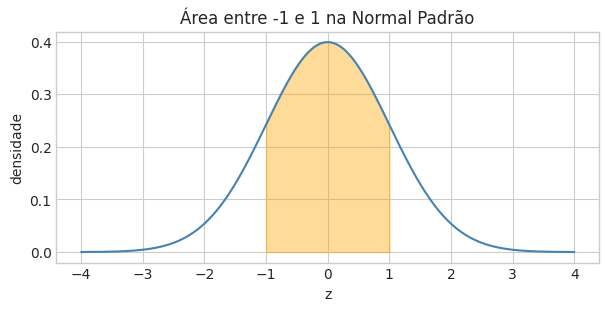

In [5]:
x_fill = np.linspace(-1, 1, 200)
y_fill = norm.pdf(x_fill, 0, 1)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.4)
plt.title("Área entre -1 e 1 na Normal Padrão")
plt.xlabel("z")
plt.ylabel("densidade")
plt.show()

🟣 **Interpretação**

| <br> A área sombreada representa: <br><br> | $ → \qquad P(-1 < Z < 1) \approx 0.68 $ |
|-|-|

- Este é o famoso **empirical rule**:

    - 68% dos valores estão em $\mu \pm 1\sigma$  
    - 95% em $\mu \pm 2\sigma$  
    - 99.7% em $\mu \pm 3\sigma$

## 8.5 Padronização (z‑score)

| Para transformar qualquer normal $N(\mu,\sigma)$ na normal padrão $N(0,1)$: | $$ → \qquad Z = \frac{X - \mu}{\sigma} $$ |
|-|-|

- Isso permite usar **uma única tabela** (tabela Z) para calcular probabilidades.

## 8.6 Visualização da CDF da normal padrão

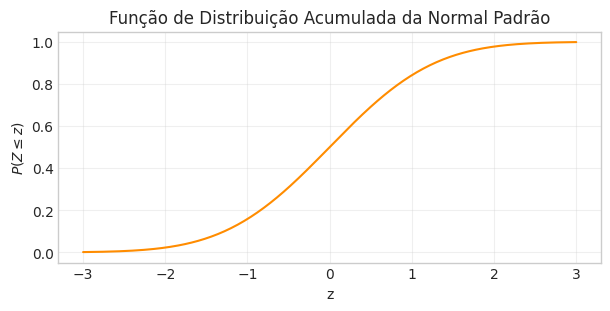

In [11]:
z_vals = np.linspace(-3, 3, 301)
cdf_vals = norm.cdf(z_vals)

plt.figure(figsize=(7, 3))
plt.plot(z_vals, cdf_vals, color="darkorange")
plt.title("Função de Distribuição Acumulada da Normal Padrão")
plt.xlabel("z")
plt.ylabel(r"$P(Z \leq z)$")
plt.grid(alpha=0.3)
plt.show()

🟣 **Leitura da CDF**

- $P(Z \le 0) = 0.5$  
- $P(Z \le 1.44) \approx 0.925$  
- $P(Z \le -2) \approx 0.0228$  

A CDF sempre cresce de 0 até 1.

### 🟠 Explicação avançada — A CDF é a integral da PDF

| Por definição: | $$ → \qquad F(z) = \int_{-\infty}^{z} f(t)\,dt $$ |
|-|-|

- Não existe forma fechada simples para essa integral, por isso usamos:
    - tabelas,
    - funções numéricas (`norm.cdf`),
    - aproximações.

<br>

---

<a id="tstudent2"></a>
[↑ Índice](#indice)
# 9. Distribuição $t$ de Student | 2

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta a distribuição $t$ como:

> - “A outra distribuição estatística comumente usada é conhecida como distribuição $T$ de Student.”

E explica que:

- foi criada por **William Sealy Gosset**, sob o pseudônimo *Student*,  
- é usada quando trabalhamos com **amostras pequenas**,  
- é fundamental para **testes t** (que serão aprofundados no módulo 5).

Vamos entender essa distribuição com profundidade e visualização.

## 9.1 Motivação: por que precisamos da distribuição t?

Quando estimamos a média populacional usando uma **amostra pequena**, o desvio padrão amostral $s$ é uma estimativa imperfeita de $\sigma$.

Isso introduz **variabilidade extra**.

A distribuição t modela exatamente essa incerteza adicional.

- Para **amostras grandes**, $s \approx \sigma$ → a distribuição t se aproxima da normal.
- Para **amostras pequenas**, a distribuição t tem **caudas mais pesadas**.

## 9.2 Definição formal

| Se $Z \sim N(0,1)$ e $V \sim \chi^2_{\nu}$ (qui‑quadrado com $\nu$ graus de liberdade), então: | $$ → \qquad T = \frac{Z}{\sqrt{V/\nu}} $$ |
|-|-|

- segue uma distribuição $t$ com $\nu$ graus de liberdade.
    - Onde:
        - $\nu$ = graus de liberdade = $n - 1$  
        - $n$ = tamanho da amostra

## 9.3 Visualização: Normal vs $t$

Vamos comparar a normal padrão com a $t$ de Student para diferentes graus de liberdade.

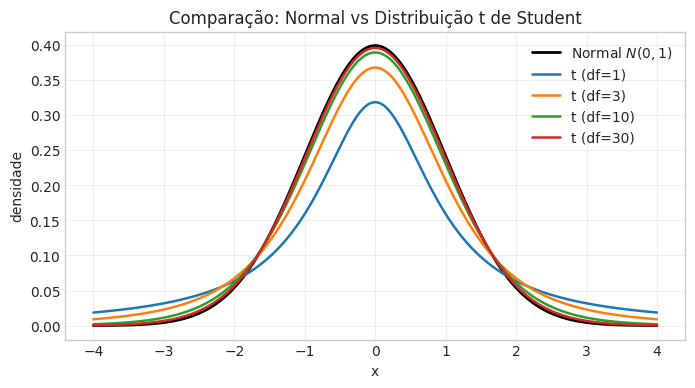

In [12]:
x = np.linspace(-4, 4, 400)

plt.figure(figsize=(8, 4))

# normal
plt.plot(x, norm.pdf(x), label="Normal $N(0,1)$", color="black", linewidth=2)

# t com diferentes graus de liberdade
for df in [1, 3, 10, 30]:
    plt.plot(x, t.pdf(x, df), label=f"t (df={df})", linewidth=1.8)

plt.title("Comparação: Normal vs Distribuição t de Student")
plt.xlabel("x")
plt.ylabel("densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- Para **df = 1**, a curva é muito mais “espalhada” (caudas pesadas).
- Para **df = 3**, ainda há bastante variabilidade.
- Para **df = 10**, já se aproxima da normal.
- Para **df = 30**, é praticamente indistinguível da normal.

👉 Quanto maior o número de graus de liberdade, mais a $t$ se aproxima da normal.

## 9.4 Por que a $t$ tem caudas mais pesadas?

Porque ela incorpora a incerteza adicional de estimar $\sigma$ a partir da amostra.

Em amostras pequenas:
- $s$ varia muito,
- isso aumenta a variabilidade de $Z/s$,
- resultando em caudas mais largas.

### 🟠 Explicação avançada — Derivação da distribuição $t$

| A distribuição $t$ surge da razão: | $$ → \qquad T = \frac{Z}{\sqrt{V/\nu}} $$ |
|-|-|
| onde: | $ → \qquad Z \sim N(0,1) $ <br> $ → \qquad V \sim \chi^2_{\nu} $ <br> $ → \qquad Z$ e $V$ são independentes |
| A densidade resultante é: | $$ → \qquad f(t;\nu) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)} {\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}} $$ |
| A presença do termo | $$ → \qquad \left(1 + \frac{t^2}{\nu}\right) $$ |

- explica as caudas mais pesadas.



## 9.5 Aplicação IBM — Diferença de médias por gênero (teaching ratings)

O curso apresenta o exemplo:

> - “A pontuação da avaliação do instrutor difere por sexo?”

Antes do teste formal (módulo 5), vamos apenas:
- visualizar as médias,
- calcular estatísticas básicas,
- entender por que a $t‑distribution$ é usada.

In [15]:
# médias por gênero
stats = ratings_df.groupby("gender")["eval"].agg(["mean", "std", "count"])
stats

,mean,std,count
gender,,,
female,3.901026,0.538803,195
male,4.069030,0.556652,268


🟣 **Interpretação**

- As médias são próximas, mas não idênticas.
- As amostras têm tamanhos diferentes.
- A variabilidade é moderada.

Isso motiva o uso da **distribuição $t$** para comparar médias.

## 9.6 Visualização das médias com intervalo de confiança aproximado

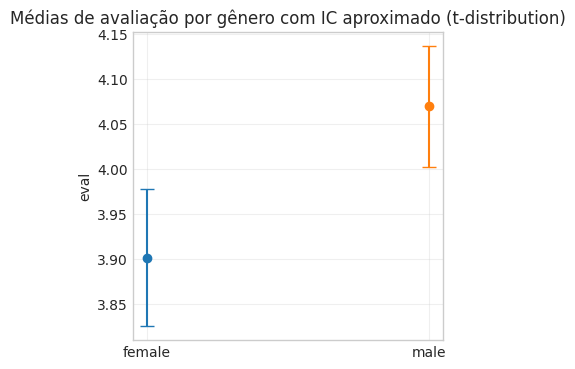

In [18]:
plt.figure(figsize=(4, 4))

for i, gender in enumerate(stats.index):
    mean = stats.loc[gender, "mean"]
    sd = stats.loc[gender, "std"]
    n = stats.loc[gender, "count"]
    se = sd / np.sqrt(n)  # erro padrão
    
    # intervalo aproximado usando t com df=n-1
    df = n - 1
    t_crit = t.ppf(0.975, df)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    
    plt.errorbar(i, mean, yerr=[[mean-ci_low], [ci_high-mean]],
                 fmt="o", capsize=5, label=gender)

plt.xticks([0, 1], stats.index)
plt.ylabel("eval")
plt.title("Médias de avaliação por gênero com IC aproximado (t-distribution)")
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- Os intervalos de confiança se sobrepõem.
- Isso sugere que a diferença pode não ser estatisticamente significativa.
- O teste formal será feito no módulo 5.

Aqui, o objetivo é entender **por que** usamos a distribuição $t$.

### 🟠 Explicação avançada — Erro padrão e $t‑critical$

| Descrição | Demostração |
|-|-|
| O erro padrão da média é: | $$ → \qquad SE = \frac{s}{\sqrt{n}} $$ |
| O intervalo de confiança baseado na $t$ é: | $$ → \qquad \bar{x} \pm t_{\alpha/2,\;n-1} \cdot SE $$ |
| Onde: | <br> $ → \qquad t_{\alpha/2,\;n-1} $ <br> $ → \qquad $ é o quantil da $ t \ com \ n-1 $ graus de liberdade. <br><br> |



<a id="teaching"></a>
[↑ Índice](#indice)
# 10. Aplicações com o dataset *teaching ratings*

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta exemplos práticos usando a variável:

- `eval` → avaliação de ensino (1 a 5)

**O objetivo é:**
- padronizar valores (z‑score),
- calcular probabilidades usando a normal,
- interpretar áreas sob a curva,
- visualizar regiões de probabilidade.

Vamos seguir exatamente essa linha, mas com explicações ampliadas.

## 10.1 Estatísticas básicas de `eval`

Antes de calcular probabilidades, precisamos da média e do desvio padrão.

In [19]:
eval_mean = ratings_df["eval"].mean()
eval_sd = ratings_df["eval"].std()
eval_mean, eval_sd

(np.float64(3.9982721362721585), np.float64(0.5548655704870065))

🟣 **Interpretação**

- `eval` tem média próxima de 4.0  
- o desvio padrão é moderado  

Isso sugere que a distribuição é concentrada entre 3 e 5.

## 10.2 Probabilidade de receber `eval > 4.5`

🔵 **Exemplo do curso IBM**

| Descrição | Demosntração |
|-|-|
| 1. Padronizar o valor 4.5: | $$ z = \frac{4.5 - \mu}{\sigma} $$ |
| 2. Usar a CDF da normal: | <br> $ P(X > 4.5) = 1 - F(z) $ <br><br> |


In [20]:
z_45 = (4.5 - eval_mean) / eval_sd
prob_less_45 = norm.cdf(z_45)
prob_greater_45 = 1 - prob_less_45
prob_greater_45

np.float64(0.18293588278210926)

🟣 **Interpretação**

| Descrição | Demosntração |
|-|-|
| A probabilidade de um instrutor receber nota **maior que 4.5** é: | <br> $ P(X > 4.5) = 1 - F(z) $ <br><br> |
| Onde: | $$ z = \frac{4.5 - \mu}{\sigma} $$ |



## 10.3 Visualização da área correspondente a `P(X > 4.5)`

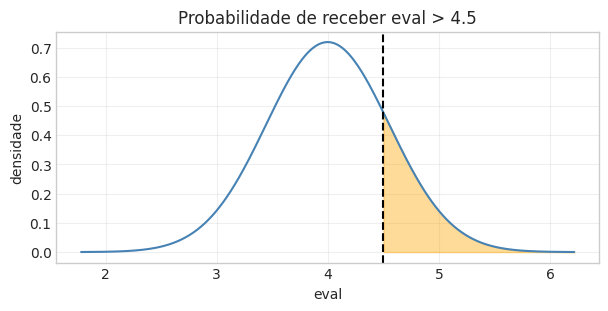

In [21]:
x = np.linspace(eval_mean - 4*eval_sd, eval_mean + 4*eval_sd, 400)
y = norm.pdf(x, eval_mean, eval_sd)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")

# área à direita de 4.5
x_fill = np.linspace(4.5, x.max(), 200)
y_fill = norm.pdf(x_fill, eval_mean, eval_sd)
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.4)

plt.axvline(4.5, color="black", linestyle="--")
plt.title("Probabilidade de receber eval > 4.5")
plt.xlabel("eval")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Leitura do gráfico**

- A área laranja representa $P(X > 4.5)$.
- Quanto maior a área, maior a probabilidade.
- A curva é centrada em $\mu \approx 4$.

## 10.4 Probabilidade de `3.5 < eval < 4.2`

🔵 **Exemplo do curso IBM**

Passos:

1. Padronizar os limites:

| $$ z_1 = \frac{3.5 - \mu}{\sigma} \qquad z_2 = \frac{4.2 - \mu}{\sigma} $$ |
|-|


2. Calcular:

| <br> $ P(3.5 < X < 4.2) = F(z_2) - F(z_1) $ |
|-|

In [22]:
x1, x2 = 3.5, 4.2

z1 = (x1 - eval_mean) / eval_sd
z2 = (x2 - eval_mean) / eval_sd

prob_interval = norm.cdf(z2) - norm.cdf(z1)
prob_interval

np.float64(0.4573159264502176)

🟣 **Interpretação**

A probabilidade de um instrutor receber nota entre **3.5 e 4.2** é:

- $ P(3.5 < X < 4.2) = F(z_2) - F(z_1) $

## 10.5 Visualização da área correspondente ao intervalo

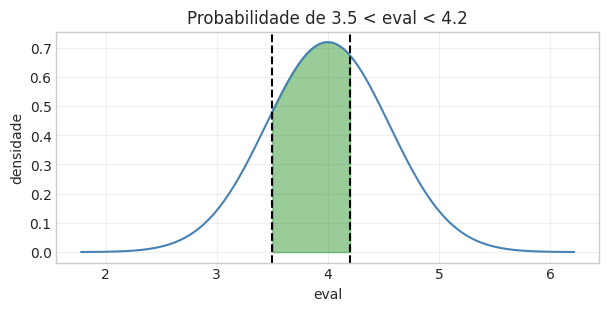

In [23]:
x_fill = np.linspace(x1, x2, 200)
y_fill = norm.pdf(x_fill, eval_mean, eval_sd)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")
plt.fill_between(x_fill, y_fill, color="green", alpha=0.4)

plt.axvline(x1, color="black", linestyle="--")
plt.axvline(x2, color="black", linestyle="--")

plt.title("Probabilidade de 3.5 < eval < 4.2")
plt.xlabel("eval")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Leitura do gráfico**

- A área verde representa o intervalo desejado.
- A maior parte da densidade está entre 3 e 5.
- O intervalo cobre uma região central da distribuição.

## 10.6 Probabilidade de valores extremos

Vamos calcular:

- $P(X < 3)$  
- $P(X > 4.8)$  

Esses valores ajudam a entender a cauda da distribuição.

In [24]:
p_less_3 = norm.cdf((3 - eval_mean) / eval_sd)
p_greater_48 = 1 - norm.cdf((4.8 - eval_mean) / eval_sd)

p_less_3, p_greater_48

(np.float64(0.035999509537429523), np.float64(0.07424232974817069))

🟣 **Interpretação**

- Notas **abaixo de 3** são raras.  
- Notas **acima de 4.8** também são raras.  

Isso confirma que a distribuição é concentrada perto de 4.

### 🟠 Explicação avançada — Probabilidade como integral da PDF

Para qualquer intervalo:

- $ P(a < X < b) = \int_a^b f(x)\,dx $

Para caudas:

- $ P(X > c) = \int_c^{\infty} f(x)\,dx $

- $ P(X < c) = \int_{-\infty}^{c} f(x)\,dx $

A função `norm.cdf` calcula exatamente essas áreas.



<a id="tabelaz"></a>
[↑ Índice](#indice)
# 11. Tabela Z — Normal Padrão

🔵 **Conteúdo oficial do módulo 4 (IBM)**

O curso apresenta a **tabela normal padrão** (tabela Z) como uma ferramenta
para encontrar probabilidades do tipo:

- $ P(Z < z) $

onde $Z \sim N(0,1)$.

A tabela Z fornece valores da **CDF da normal padrão**.

## 11.1 Como funciona a tabela Z?

A tabela Z é organizada assim:

- **linhas** → primeiro dígito + primeiro decimal  
- **colunas** → segundo decimal  

**Exemplo:**

- Para encontrar:

    - $ P(Z < 1.44) $

        - linha: **1.4**  
        - coluna: **0.04**  

- A interseção fornece:

    - $ P(Z < 1.44) \approx 0.925 $

## 11.2 Exemplo IBM — Probabilidade para z = 1.44

Vamos confirmar usando Python.

In [28]:
norm.cdf(1.44)

np.float64(0.925066300465673)

🟣 **Interpretação**

O valor coincide com o da tabela:

- $ P(Z < 1.44) \approx 0.925 $

## 11.3 Visualização gráfica da área correspondente

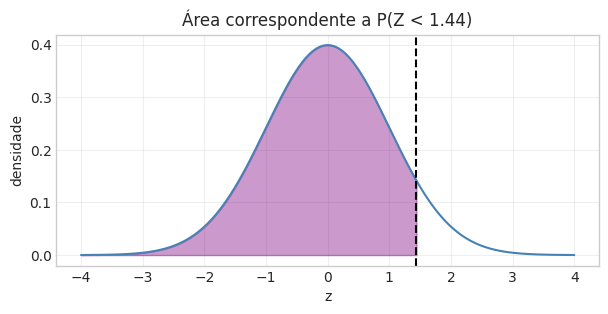

In [29]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color="steelblue")

# área até 1.44
x_fill = np.linspace(-4, 1.44, 300)
y_fill = norm.pdf(x_fill)
plt.fill_between(x_fill, y_fill, color="purple", alpha=0.4)

plt.axvline(1.44, color="black", linestyle="--")
plt.title("Área correspondente a P(Z < 1.44)")
plt.xlabel("z")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Leitura do gráfico**

- A área roxa representa $P(Z < 1.44)$.
- A área total sob a curva é 1.
- A tabela Z fornece exatamente essa área acumulada.

## 11.4 Exemplo — Probabilidade à direita

Para encontrar:

- $ P(Z > 1.44) $

usamos:

- $ P(Z > 1.44) = 1 - P(Z < 1.44) $

In [30]:
1 - norm.cdf(1.44)

np.float64(0.07493369953432705)

🟣 **Interpretação**

- A área à direita de 1.44 é pequena.
- Isso indica que valores acima de 1.44 são relativamente raros.

## 11.5 Exemplo — Probabilidade entre dois valores

Para:

- $ P(0.5 < Z < 1.2) $

usamos:

- $ P(0.5 < Z < 1.2) = F(1.2) - F(0.5) $

In [31]:
prob_interval = norm.cdf(1.2) - norm.cdf(0.5)
prob_interval

np.float64(0.19346786850427866)

🟣 **Interpretação**

- A área entre 0.5 e 1.2 representa uma região central da curva.
- A tabela Z permite calcular isso manualmente.

### 🟠 Explicação avançada — Por que a tabela Z funciona?

A tabela Z funciona porque a normal padrão tem PDF:

- $ f(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2} $

A CDF é:

- $ F(z) = \int_{-\infty}^{z} f(t)\,dt $

Essa integral **não tem forma fechada simples**, então:

- historicamente, tabelas eram usadas,
- hoje usamos `norm.cdf`,
- mas a tabela continua sendo uma ferramenta didática importante.

</details>

## 11.6 Tabela Z — Estrutura e Geração

A Tabela Z apresenta valores da função de distribuição acumulada (CDF) da Normal padrão:

- $Z ~ N(0,1)$

Ela informa probabilidades do tipo:

- $P(Z ≤ z)$

### Estrutura da Tabela Z

A tabela tradicional é organizada assim:

- **31 linhas**: valores de z de $0.0 até 3.0$, em passos de $0.1$  
- **10 colunas**: valores decimais de $0.00 até 0.09$, em passos de $0.01$  

Isso gera:

- 31 linhas × 10 colunas = 310 valores

    | Exemplo de linhas: | Exemplo de colunas: |
    |-|-|
    | 0.0 | 0.00 | 
    | 0.1 | 0.01 |
    | 0.2 | 0.02 |
    | ... | ... | 
    | 3.0 | 0.09 | 



### Gerando uma Tabela Z computada (sem copyright)

O código abaixo cria uma tabela Z completa usando cálculos da Normal padrão:

In [32]:
# gera tabela Z computada
rows = np.arange(0.0, 3.1, 0.1)
cols = np.arange(0.00, 0.10, 0.01)

table = pd.DataFrame(
    [[norm.cdf(r + c) for c in cols] for r in rows],
    index=[f"{r:.1f}" for r in rows],
    columns=[f"{c:.2f}" for c in cols]
)

table

,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.0,0.500000,0.503989,0.507978,0.511966,0.515953,0.519939,0.523922,0.527903,0.531881,0.535856
0.1,0.539828,0.543795,0.547758,0.551717,0.555670,0.559618,0.563559,0.567495,0.571424,0.575345
0.2,0.579260,0.583166,0.587064,0.590954,0.594835,0.598706,0.602568,0.606420,0.610261,0.614092
0.3,0.617911,0.621720,0.625516,0.629300,0.633072,0.636831,0.640576,0.644309,0.648027,0.651732
0.4,0.655422,0.659097,0.662757,0.666402,0.670031,0.673645,0.677242,0.680822,0.684386,0.687933
0.5,0.691462,0.694974,0.698468,0.701944,0.705401,0.708840,0.712260,0.715661,0.719043,0.722405
0.6,0.725747,0.729069,0.732371,0.735653,0.738914,0.742154,0.745373,0.748571,0.751748,0.754903
0.7,0.758036,0.761148,0.764238,0.767305,0.770350,0.773373,0.776373,0.779350,0.782305,0.785236
0.8,0.788145,0.791030,0.793892,0.796731,0.799546,0.802337,0.805105,0.807850,0.810570,0.813267
0.9,0.815940,0.818589,0.821214,0.823814,0.826391,0.828944,0.831472,0.833977,0.836457,0.838913


<b> </b>

<a id="exercicios"></a>
[↑ Índice](#indice)
# 12. Exercícios Guiados

🔵 **Objetivo (IBM)**

Consolidar os conceitos do módulo 4:

- probabilidade,
- variáveis aleatórias,
- PMF, PDF, CDF,
- distribuição normal,
- distribuição t,
- z‑score,
- cálculo de áreas sob a curva,
- interpretação de probabilidades,
- uso da tabela Z.

Estes exercícios preparam você para o **módulo 5 — Hypothesis Testing**.

---
## 📝 Exercício 1 — Probabilidade na Normal Padrão

Calcule:

1. $P(Z < 1.25)$  
2. $P(Z > 2)$  
3. $P(-1 < Z < 1.8)$  

Use `norm.cdf()`.

In [26]:
# TODO: seu código aqui
# Exemplo:
p1 = norm.cdf(1.25)
p1

np.float64(0.8943502263331446)

---
## 📝 Exercício 2 — Probabilidade com `eval`

Usando a distribuição normal ajustada para `eval`:

1. Calcule $P(X < 3.8)$  
2. Calcule $P(X > 4.6)$  
3. Calcule $P(3.9 < X < 4.3)$  

Dica: padronize usando:

$$
z = \frac{x - \mu}{\sigma}
$$

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 3 — Intervalos de probabilidade

Considere a normal padrão.

1. Encontre $z$ tal que $P(Z < z) = 0.975$  
2. Encontre $z$ tal que $P(Z > z) = 0.10$  
3. Encontre $z$ tal que $P(-z < Z < z) = 0.90$  

Dica: use `norm.ppf()`.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 4 — Distribuição t

Para uma t com 12 graus de liberdade:

1. Calcule $P(T < 1.5)$  
2. Calcule $P(T > 2.2)$  
3. Calcule $P(-1 < T < 1)$  

Dica: use `t.cdf(x, df)`.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 5 — Comparação Normal vs t

Para df = 5:

1. Compare $P(T > 2)$ com $P(Z > 2)$  
2. Compare $P(|T| > 2)$ com $P(|Z| > 2)$  

Interprete a diferença entre as caudas.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 6 — Aplicação com teaching ratings

Usando `eval_mean` e `eval_sd`:

1. Qual a probabilidade de um instrutor receber nota **abaixo de 3.2**?  
2. Qual a probabilidade de receber nota **acima de 4.7**?  
3. Qual a probabilidade de receber nota entre **3.8 e 4.4**?  

Faça também um gráfico sombreando a área correspondente ao item 3.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 7 — Tabela Z

Usando apenas `norm.cdf()`:

1. Verifique o valor da tabela para $z = 0.93$  
2. Verifique o valor da tabela para $z = -1.28$  
3. Calcule $P(Z > 1.64)$  

Compare com os valores da tabela normal padrão.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 8 — Visualização

Plote a PDF da normal padrão e destaque:

- a área entre −1 e 1  
- a área entre −2 e 2  
- a área entre −3 e 3  

Use cores diferentes para cada intervalo.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 9 — Explorando a distribuição t

Plote a PDF da t‑distribution para:

- df = 2  
- df = 5  
- df = 10  
- df = 30  

Compare com a normal padrão.

In [ ]:
# TODO: seu código aqui

---
## 📝 Exercício 10 — Interpretação conceitual

Responda em texto:

1. Por que a distribuição t tem caudas mais pesadas que a normal?  
2. O que significa padronizar uma variável?  
3. Por que a área sob a PDF é igual a 1?  
4. Qual a diferença entre PDF e CDF?  
5. Por que usamos a tabela Z?  

Escreva respostas claras e concisas.

In [ ]:
# TODO: escreva suas respostas aqui (em markdown)

<b> </b>

<a id="apendice"></a>
[↑ Índice](#indice)
# 13. Apêndice Matemático Avançado

🟠 **Esta seção é opcional.**

Ela aprofunda:
- demonstrações formais,
- propriedades matemáticas,
- conexões entre distribuições,
- derivação da normal,
- relação entre normal, qui‑quadrado e t,
- propriedades da CDF e PDF,
- resultados clássicos da teoria das probabilidades.

Use esta seção como referência teórica.

<br>

## 13.1 Propriedades fundamentais da média e variância

| Propriedade | Função |
|-|-|
|🔹 **Soma dos desvios em relação à média:** | <br> $ → \qquad  \sum_{i=1}^n (x_i - \bar{x}) = 0 $ <br><br> |
|🔹 **Variância amostral:** | <br> $ → \qquad  s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2 $ <br><br> |
|🔹 **Variância populacional:** | <br> $ → \qquad \sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2 $ <br><br> |

### 🟠 Demonstração — Soma dos desvios é zero

| Step by Step | Função |
|-|-|
| Começamos com: | <br> $ → \qquad \bar{x} = \frac{1}{n} \sum_{i=1}^n x_i $ <br><br> |
| Então: | <br> $ → \qquad \sum_{i=1}^n (x_i - \bar{x}) = \sum_{i=1}^n x_i - \sum_{i=1}^n \bar{x} $ <br><br> |
| Como $\bar{x}$ é constante: | <br> $ → \qquad \sum_{i=1}^n \bar{x} = n\bar{x} $ <br><br> |
| Logo: | <br> $ → \qquad \sum_{i=1}^n (x_i - \bar{x}) = \sum_{i=1}^n x_i - n\bar{x} = n\bar{x} - n\bar{x} = 0 $ <br><br> |

<br>

## 13.2 Derivação da PDF da Normal

| A PDF da normal é: | <br> $$ → \qquad f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) $$ <br> |
|-|-|

- onde: $e^{u} \ \equiv \ exp(u)$


Ela surge da exigência de que:
- seja simétrica,
- tenha decaimento suave,
- tenha área total igual a 1.

### 🟠 Demonstração — Integral da normal usando coordenadas polares


| Step by step | Função |
|-|-|
| **Queremos mostrar:** | <br> **$ →  \qquad \int_{-\infty}^{+\infty} e^{-x^2/2}\,dx = \sqrt{2\pi} $** <br><br> |
| 1. Considere: | <br> $ → \qquad I = \int_{-\infty}^{+\infty} e^{-x^2/2}\,dx $ <br><br> |
| 2. Então: | <br> $ → \qquad I^2 = \int_{-\infty}^{+\infty} \int_{-\infty}^{+\infty} e^{-(x^2+y^2)/2}\,dx\,dy $ <br><br>  |
| 3. Converta para coordenadas polares: | <br> $  →  \qquad x^2 + y^2 = r^2 $ <br> $ →  \qquad  dx\,dy = r\,dr\,d\theta $ <br><br> |
| 4. A integral vira: | <br> $ → \qquad I^2 = \int_0^{2\pi} \int_0^{\infty} e^{-r^2/2} r\,dr\,d\theta $ <br><br> |
| 5. Resolva a integral interna: | <br> $ → \qquad \int_0^{\infty} r e^{-r^2/2}\,dr = 1 $ <br><br> |
| 6. Logo: | <br> $ → \qquad I^2 = 2\pi \quad\Rightarrow\quad I = \sqrt{2\pi} $ <br><br> |

<br>

## 13.3 Relação entre Normal, Qui‑Quadrado e t‑Distribution

Essas três distribuições estão profundamente conectadas.

| Distribuições | Função |
|-|-|
|🔹 **Normal** | <br> $$ →  \qquad  Z \sim N(0,1) $$ <br><br> |
|🔹 **Qui‑quadrado** <br><br> Se $Z_1, \dots, Z_k$ são independentes e $N(0,1)$:<br><br> | <br> $ →  \qquad \chi^2_k = \sum_{i=1}^k Z_i^2 $ <br><br> |
|🔹 **t‑distribution** <br><br> Se: <br> - $Z \sim N(0,1)$ <br> - $V \sim \chi^2_\nu$ <br> - $Z$ e $V$ independentes <br><br> **então:** <br><br> | <br> $ →  \qquad T = \frac{Z}{\sqrt{V/\nu}} $ <br><br> |



- segue uma distribuição t com $\nu$ graus de liberdade.

<br>

### 🟠 Demonstração — Por que a $t$ tem caudas mais pesadas?

A variância de $T$ é maior que a da normal porque:

- o denominador $\sqrt{V/\nu}$ varia muito quando $\nu$ é pequeno,
- isso aumenta a variabilidade de $T$,
- resultando em caudas mais largas.

| Formalmente: | <br> $ →  \qquad T = \frac{Z}{\sqrt{V/\nu}} $ <br><br> |
|-|-|

- Quando $\nu$ é pequeno, $V/\nu$ tem alta variância $→$ o denominador oscila $→ T$ assume valores extremos com maior frequência.

<br>

## 13.4 Propriedades da CDF

Para qualquer variável contínua:

- $F(x)$ é crescente  
- $\lim_{x\to -\infty} F(x) = 0$  
- $\lim_{x\to +\infty} F(x) = 1$  
- $F'(x) = f(x)$ (quando a PDF existe)

<br>

## 13.5 Propriedades da PDF

| Propriedades | Demonstração |
|-|-|
| Função: | <br> $ →  \qquad f(x) \ge 0 $ <br><br> |
| A área total é 1: | <br> $ →  \qquad \int_{-\infty}^{+\infty} f(x)\,dx = 1 $ <br><br> |
| Probabilidades são áreas: | <br> $ →  \qquad P(a < X < b) = \int_a^b f(x)\,dx $ <br><br> |

<br>

## 13.6 Aproximação Normal da Binomial

| Aproximação | Demonstração |
|-|-|
| Quando: | <br> $ →  \qquad np \ge 5 \quad\text{e}\quad n(1-p) \ge 5 $ <br><br> |
| Então: | <br> $ →  \qquad Bin(n,p) \approx N(np,\;np(1-p)) $ <br><br> | 

<br>

### 🟠 Demonstração — Binomial como soma de Bernoullis

| Binomial | Demosntração |
|-|-|
| A binomial pode ser escrita como: | <br> $ →  \qquad Bin(n,p) = \sum_{i=1}^n Bernoulli(p) $ <br><br> |
| Pelo Teorema Central do Limite: | <br> $ →  \qquad \sum_{i=1}^n Bernoulli(p) \approx N(np,\;np(1-p)) $ <br><br> |

<br>

## 13.7 Lei dos Grandes Números (LLN)

| Lei | Demonstração |
|-|-|
| A média amostral converge para a média populacional: | <br> $ →  \qquad \bar{X}_n \to \mu $ <br> $ →  \qquad quando \ n \to \infty$ <br><br> |
| <br> 🟠 Forma forte da LLN <br> $ → $ A convergência ocorre **quase certamente** <br><br> | <br> $ →  \qquad P\left(\lim_{n\to\infty} \bar{X}_n = \mu \right) = 1 $ <br><br> |


<br>

## 13.8 Teorema Central do Limite (TCL)

| Se $X_1,\dots,X_n$ são i.i.d. com média $\mu$ e variância $\sigma^2$: | $$ →  \qquad \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \Rightarrow N(0,1) $$ $ →  \qquad conforme \ n \to \infty$ <br><br> |
|-|-|

.

### 🟠 Esboço da demonstração via funções características

1. A função característica da soma de variáveis independentes é o produto das funções características.  
2. Expandindo em série de Taylor, o termo dominante é quadrático.  
3. Isso leva à forma exponencial da normal.  

</details>

# Post linkedIn do assunto deste notebook 

z-score 💡

O gráfico abaixo mostra a distribuição das avaliações (de 1 a 5) dadas pelos alunos aos seus professores e destaca a densidade correspondente a “avaliações acima de 4.5”.  
Mesmo sem saber estatística, você consegue interpretar o que está acontecendo:  

▪️1. A curva representa a distribuição dos dados  
→ Ela mostra onde os valores são mais comuns (o topo do “sino”) e onde são raros (as extremidades).

▪️2. A linha vertical marca o ponto que queremos analisar  
→ Aqui, 4.5 — uma nota alta.

▪️3. A área colorida representa a probabilidade  
→ Quanto maior a área, maior a chance de observar uma avaliação acima desse ponto.  
→ Quanto menor a área, mais raro é o evento.

▪️4. O z‑score traduz isso em linguagem universal  
→ Ele responde:  
❓ “Quão distante esse valor está da média(µ) (≈ 4), em unidades de desvio padrão(σ)?”  
É uma forma padronizada de comparar qualquer valor com o comportamento geral dos dados.

A interpretação é simples:   
→ Área pequena → evento raro  
→ Área grande → evento comum  
Essa leitura visual já indica se estamos diante de algo esperado ou excepcional.

📈 Estatística é isso: Uma forma de medir quão provável é que um evento aconteça e transformar dados em decisões.

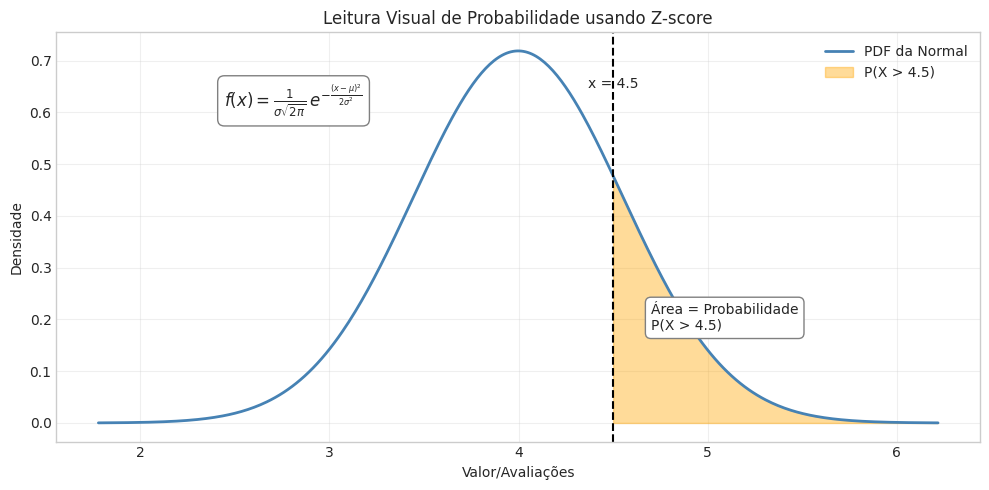

In [36]:
# parâmetros da distribuição
mu = eval_mean
sigma = eval_sd

# eixo x
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
y = norm.pdf(x, mu, sigma)

# ponto de corte
cut = 4.5
x_fill = np.linspace(cut, x.max(), 200)
y_fill = norm.pdf(x_fill, mu, sigma)

plt.figure(figsize=(10, 5))

# curva principal
plt.plot(x, y, color="steelblue", linewidth=2, label="PDF da Normal")

# área sombreada
plt.fill_between(x_fill, y_fill, color="orange", alpha=0.4, label="P(X > 4.5)")

# linha vertical
plt.axvline(cut, color="black", linestyle="--", linewidth=1.5)
plt.text(cut, max(y)*0.9, "x = 4.5", ha="center", fontsize=10)

# anotação da fórmula da PDF
plt.text(mu - 2.8*sigma, max(y)*0.85,
         r"$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\,e^{-\frac{(x-\mu)^2}{2\sigma^2}}$",
         fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray"))

# anotação da área
plt.text(cut + 0.2, max(y)*0.25,
         "Área = Probabilidade\nP(X > 4.5)",
         fontsize=10, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray"))

plt.title("Leitura Visual de Probabilidade usando Z-score")
plt.xlabel("Valor/Avaliações")
plt.ylabel("Densidade")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
